In [36]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import seaborn as sns

**Identifiant :**	Identifiant du Client dans la base

**Montant :**	Montant du crédit accordé

**Duree :**	Durée du crédit accordé

**Charges_Client :**	Charges budgétaire du client (loyer, autres crédits, etc.. )

**Ressources_Client :**	Revenus au budget du client (Salaires, autres revenus,.. )

**Nb_emprunteurs :**	Nombre de personnes qui ont signé le contrat (1 ou 2)

**Assurance :**	Est-ce que le compte est assuré ? (Oui=1)

**Telephone :**	Est-ce que le client a donné son numéro de téléphone ? (Oui=1)

**Client :** Est-ce que le client a déjà eu des comptes dans cette société avant l'ouverture de ce crédit ? (Oui=1)

**Taux_interet :**	Taux d'intérêt du crédit

**Payeur**	Comportement Paiement du client (1=Mauvais Payeur, 0=Bon Payeur)


In [37]:
data = pd.read_csv('scoring_risque.csv',sep='|')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Identifiant        1134 non-null   int64  
 1   Montant            1134 non-null   int64  
 2   Duree              1134 non-null   int64  
 3   Telephone          1134 non-null   int64  
 4   Taux_interet       1134 non-null   float64
 5   Ressources_Client  1134 non-null   float64
 6   Charges_Client     1134 non-null   float64
 7   Nb_emprunteurs     1134 non-null   int64  
 8   Assurance          1134 non-null   int64  
 9   Client             1134 non-null   int64  
 10  Payeur             1134 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 97.6 KB


In [38]:
data.drop('Identifiant', axis=1, inplace=True)
data['Telephone'] = data['Telephone'].astype('category')
data['Assurance'] = data['Assurance'].astype('category')
data['Client'] = data['Client'].astype('category')
data['Payeur'] = data['Payeur'].astype('category')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Montant            1134 non-null   int64   
 1   Duree              1134 non-null   int64   
 2   Telephone          1134 non-null   category
 3   Taux_interet       1134 non-null   float64 
 4   Ressources_Client  1134 non-null   float64 
 5   Charges_Client     1134 non-null   float64 
 6   Nb_emprunteurs     1134 non-null   int64   
 7   Assurance          1134 non-null   category
 8   Client             1134 non-null   category
 9   Payeur             1134 non-null   category
dtypes: category(4), float64(3), int64(3)
memory usage: 57.8 KB


In [39]:
data.describe(include='all')

,Montant,Duree,Telephone,Taux_interet,Ressources_Client,Charges_Client,Nb_emprunteurs,Assurance,Client,Payeur
count,1134.000000,1134.000000,1134.0,1134.000000,1134.000000,1134.000000,1134.000000,1134.0,1134.0,1134.0
unique,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0
top,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,0.0
freq,NaN,NaN,828.0,NaN,NaN,NaN,NaN,607.0,675.0,983.0
mean,7867.901235,45.216931,NaN,8.232963,2845.355062,830.530152,1.538801,NaN,NaN,NaN
std,3944.982580,13.981220,NaN,1.015901,1997.330441,958.908800,0.498712,NaN,NaN,NaN
min,1500.000000,12.000000,NaN,3.420000,300.000000,1.000000,1.000000,NaN,NaN,NaN
25%,5000.000000,36.000000,NaN,8.220000,1776.477500,450.000000,1.000000,NaN,NaN,NaN
50%,7000.000000,48.000000,NaN,8.520000,2468.995000,681.791666,2.000000,NaN,NaN,NaN
75%,10000.000000,60.000000,NaN,8.520000,3290.032500,995.000000,2.000000,NaN,NaN,NaN


In [40]:
data.corr(numeric_only=True)

,Montant,Duree,Taux_interet,Ressources_Client,Charges_Client,Nb_emprunteurs
Montant,1.000000,0.391553,-0.020400,0.277674,0.219811,0.169089
Duree,0.391553,1.000000,0.583415,-0.135873,-0.078974,0.116514
Taux_interet,-0.020400,0.583415,1.000000,-0.204952,-0.106552,-0.003764
Ressources_Client,0.277674,-0.135873,-0.204952,1.000000,0.813041,0.210039
Charges_Client,0.219811,-0.078974,-0.106552,0.813041,1.000000,0.104635
Nb_emprunteurs,0.169089,0.116514,-0.003764,0.210039,0.104635,1.000000


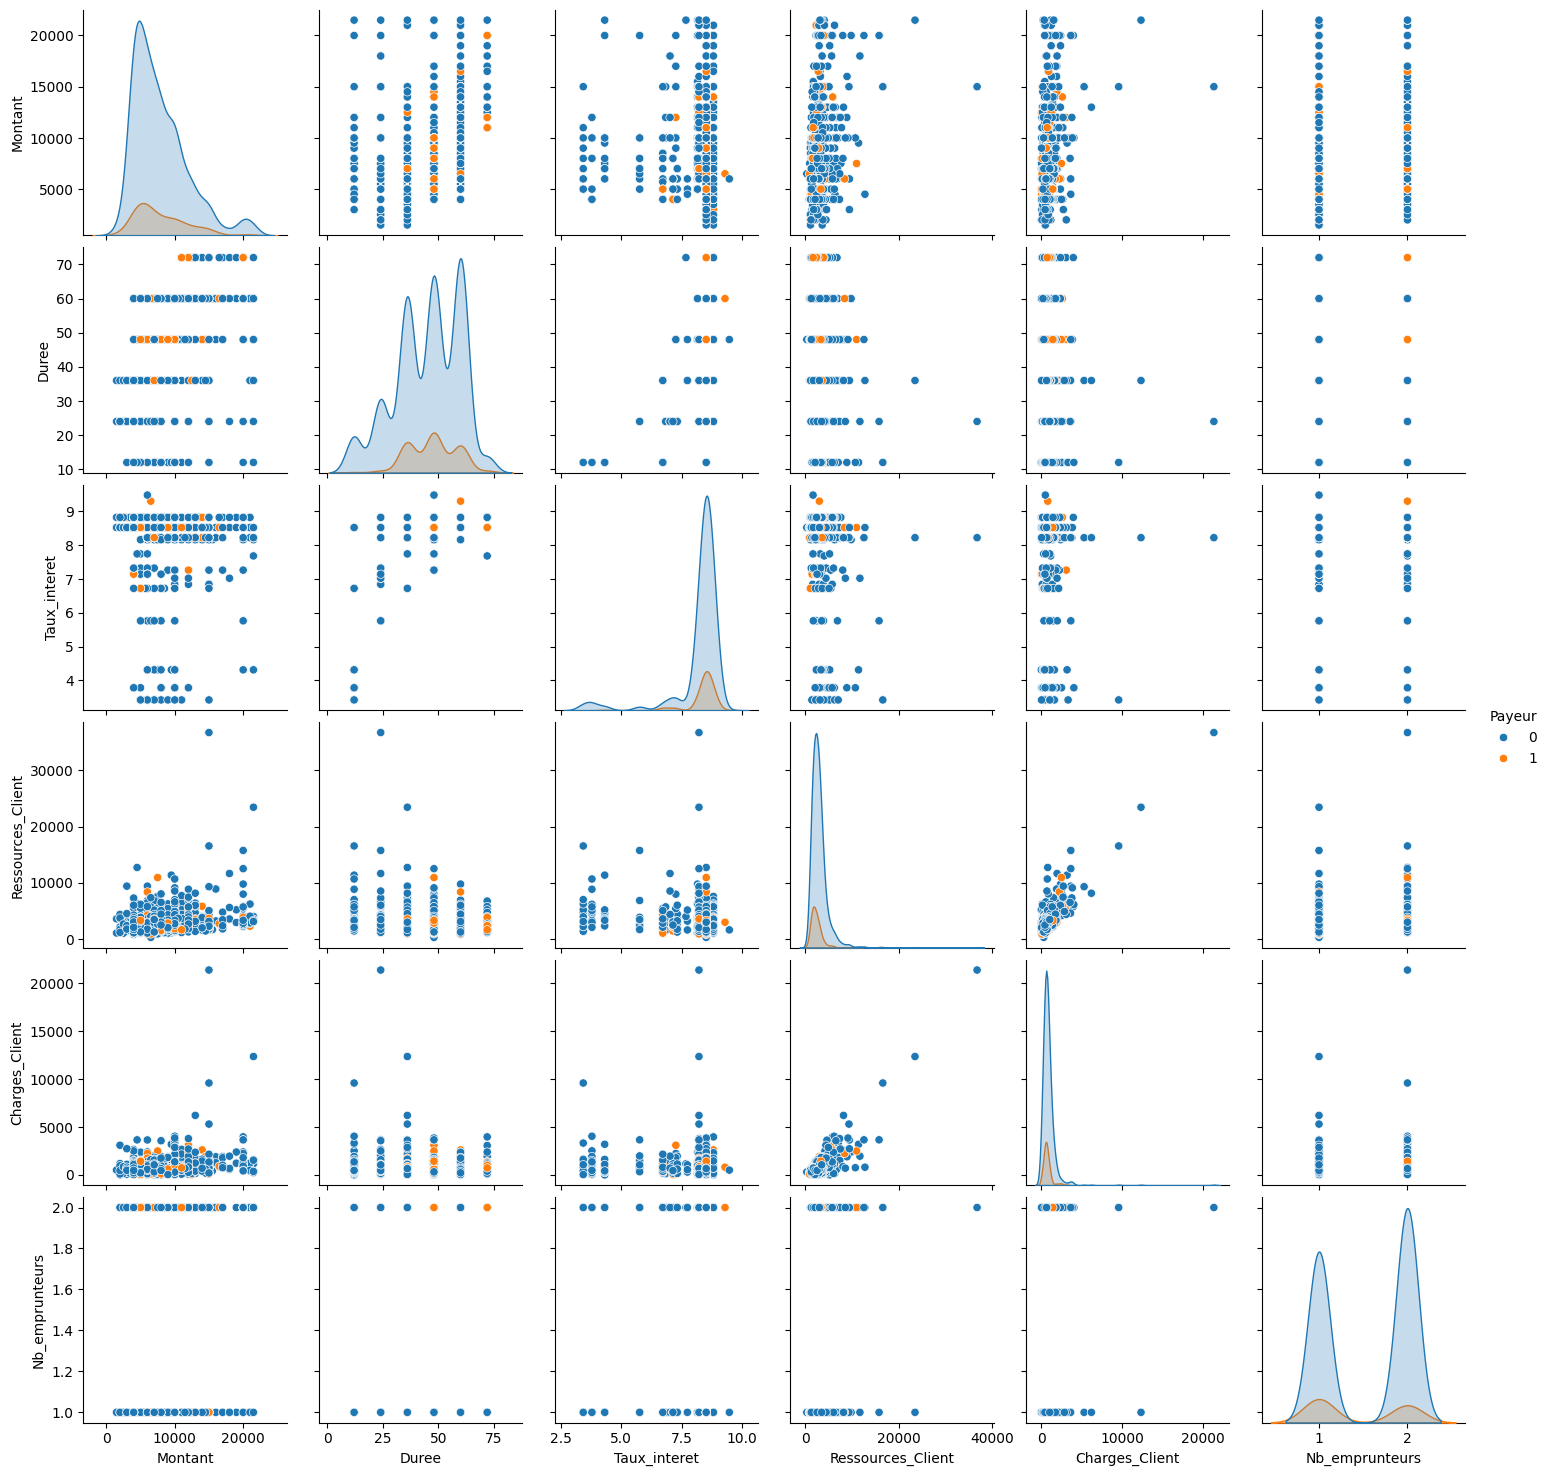

In [41]:
sns.pairplot(data, hue="Payeur")

In [42]:
def evaluate_classification_model(y_true, y_pred, model):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=model.classes_,
        display_labels=model.classes_,
    )

In [43]:
train , test = train_test_split(data, test_size=0.2, random_state=0, stratify=data['Payeur'])

X_train = train.drop('Payeur', axis=1)
y_train = train['Payeur']
X_test = test.drop('Payeur', axis=1)
y_test = test['Payeur']

Accuracy : 0.6079295154185022
F1 score : 0.32061068702290074


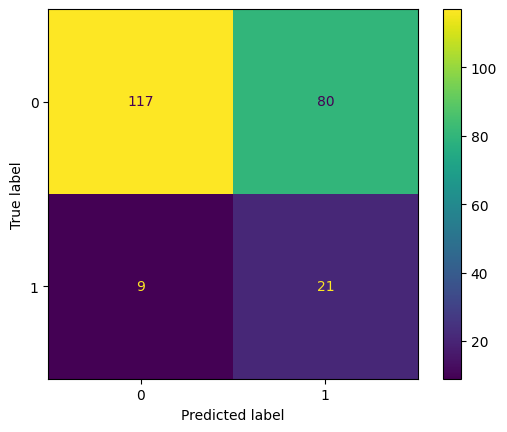

In [44]:
lr = LogisticRegression(C=0.1, l1_ratio=0, solver='liblinear', max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

Accuracy : 0.7841409691629956
F1 score : 0.24615384615384617


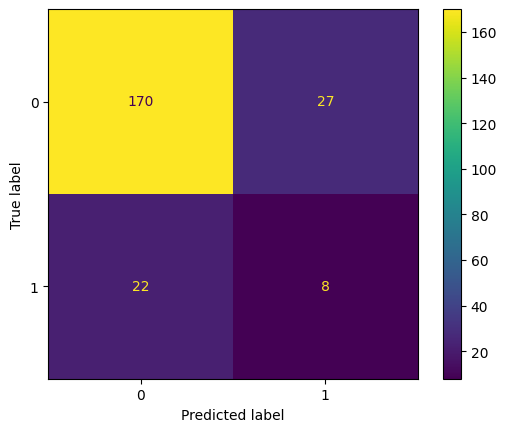

In [53]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)

Accuracy : 0.5330396475770925
F1 score : 0.28378378378378377


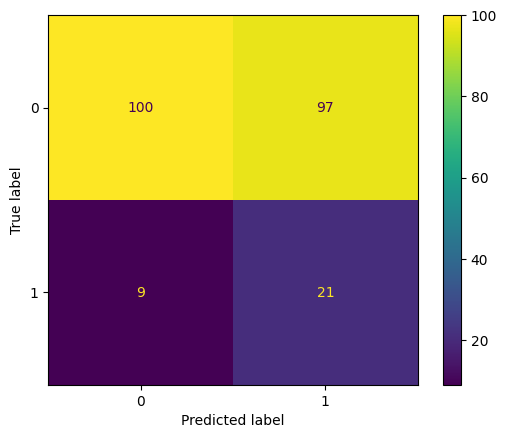

In [54]:
dtc = DecisionTreeClassifier(max_depth=5,class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)

[Text(0.5404411764705882, 0.9166666666666666, 'Ressources_Client <= 2016.775\ngini = 0.231\nsamples = 907\nvalue = [786, 121]'),
 Text(0.2867647058823529, 0.75, 'Ressources_Client <= 1989.5\ngini = 0.319\nsamples = 311\nvalue = [249, 62]'),
 Text(0.41360294117647056, 0.8333333333333333, 'True  '),
 Text(0.16176470588235295, 0.5833333333333334, 'Ressources_Client <= 1077.5\ngini = 0.304\nsamples = 300\nvalue = [244, 56]'),
 Text(0.08823529411764706, 0.4166666666666667, 'Duree <= 54.0\ngini = 0.49\nsamples = 14\nvalue = [8, 6]'),
 Text(0.058823529411764705, 0.25, 'Montant <= 7000.0\ngini = 0.496\nsamples = 11\nvalue = [5, 6]'),
 Text(0.029411764705882353, 0.08333333333333333, 'gini = 0.444\nsamples = 9\nvalue = [3, 6]'),
 Text(0.08823529411764706, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.11764705882352941, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.23529411764705882, 0.4166666666666667, 'Duree <= 30.0\ngini = 0.289\nsamples = 286\nvalue = [2

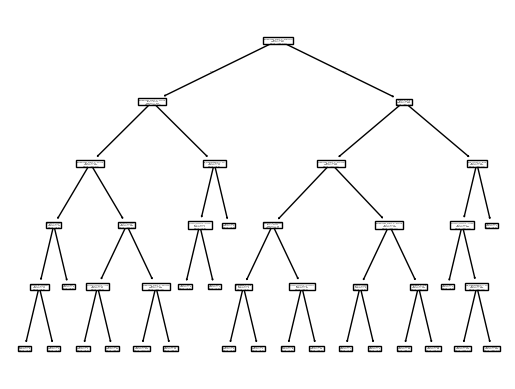

In [48]:
plot_tree(dtc, feature_names=X_train.columns)

In [55]:
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier

Accuracy : 0.8678414096916299
F1 score : 0.0625


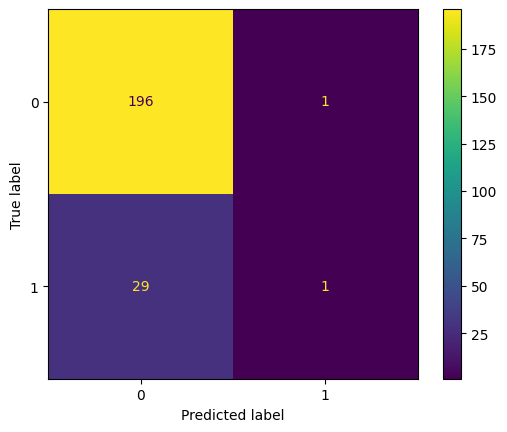

In [56]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)

Accuracy : 0.8502202643171806
F1 score : 0.15


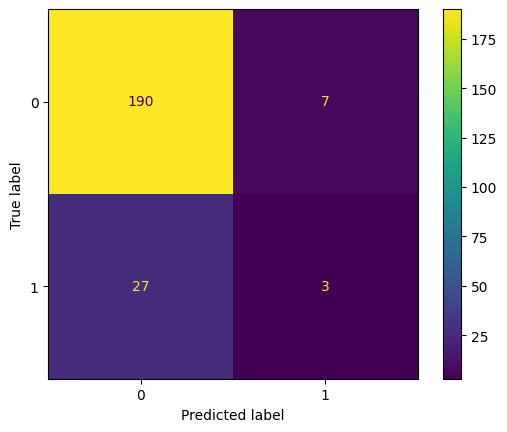

In [57]:
rfc = RandomForestClassifier(max_depth=10,class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)

Accuracy : 0.8370044052863436
F1 score : 0.05128205128205128


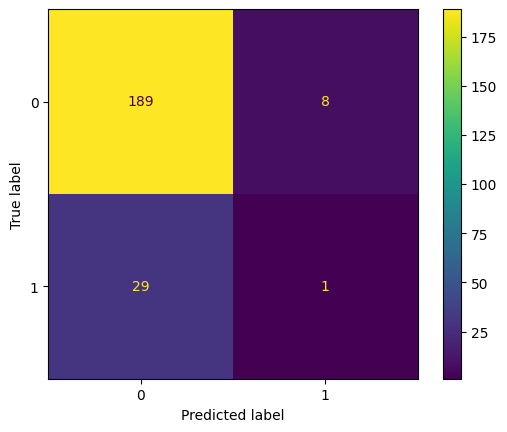

In [59]:
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbc.fit(X_train, y_train)
y_pred = gbc.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 score :', f1_score(y_test, y_pred))
_ = ConfusionMatrixDisplay.from_estimator(gbc, X_test, y_test)